# **Precision, Recall & F1-Score**



##  Why Do We Need These Metrics?

When evaluating classification models (especially binary classification), **accuracy** alone can be misleading.  
For example — in a dataset where 95% of samples are *negative*, a model that always predicts "negative" will achieve 95% accuracy but will be **useless**.

To overcome this, we use **Precision**, **Recall**, and **F1-Score**, which tell us:
- How good the model is at **detecting positives**
- How many **false alarms** it raises
- How **balanced** its performance is between precision and recall

---

##  The Confusion Matrix Reminder

Before understanding these metrics, recall the confusion matrix structure:

|                      | **Predicted: Positive** | **Predicted: Negative** |
|----------------------|-------------------------|-------------------------|
| **Actual: Positive** | True Positive (TP)      | False Negative (FN)     |
| **Actual: Negative** | False Positive (FP)     | True Negative (TN)      |

Each metric is derived from these four numbers.

---

##  Precision — “When we predict positive, how often are we correct?”

Precision measures **how accurate the positive predictions are**.

\[
\text{Precision} = \frac{TP}{TP + FP}
\]

- High precision → few false positives (model rarely cries "wolf" when there isn’t one)
- Low precision → model incorrectly labels many negatives as positives

###  Example:
If your spam detector marks 100 emails as spam, and 90 are actually spam:  
\[
\text{Precision} = \frac{90}{100} = 0.9
\]
→ 90% of the time, the model is correct when it says “Spam.”

---

##  Recall — “When it’s actually positive, how often do we catch it?”

Recall (also known as **Sensitivity** or **True Positive Rate**) measures **how many actual positives the model correctly identified.**

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

- High recall → model finds most positives, but might include false positives.
- Low recall → model misses many actual positives.

###  Example:
If there are 100 spam emails in total, and your model detects 90 of them:
\[
\text{Recall} = \frac{90}{100} = 0.9
\]
→ The model caught 90% of actual spam.

---

##  The Precision–Recall Tradeoff

There’s often a **tradeoff** between precision and recall.

- If you make your model **stricter** (predict positive only when very sure), you’ll get:
  -  Higher precision
  -  Lower recall

- If you make your model **lenient** (predict positive often), you’ll get:
  -  Higher recall
  -  Lower precision

Balancing both depends on your **use case**:
| Application | Which matters more? |
|--------------|---------------------|
| Spam Detection | Recall (catch all spam) |
| Fraud Detection | Recall (catch all fraud) |
| Medical Tests | Recall (don’t miss positives) |
| Email Auto-Sorting | Precision (avoid false alarms) |

---

##  F1-Score — The Balance Between Precision & Recall

The **F1-Score** is the **harmonic mean** of precision and recall.  
It gives a single number that balances both metrics.

\[
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
\]

###  Why Harmonic Mean?
The harmonic mean **penalizes extreme values**.  
If one metric is very low (say precision = 0.1, recall = 0.9),  
then F1 will still be low → it forces a balance.

---



##  Why We Use These Metrics

| Metric | Measures | Best When |
|--------|-----------|------------|
| **Precision** | Correctness of positive predictions | False positives are costly |
| **Recall** | Completeness of positive predictions | Missing positives is costly |
| **F1-Score** | Balance of both | You need a single combined metric |

---

##  Quick Summary

| Metric | Formula | Focus |
|:--------|:----------|:-------|
| **Precision** | TP / (TP + FP) | How *exact* positive predictions are |
| **Recall** | TP / (TP + FN) | How many actual positives we caught |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Overall balance between precision & recall |

---

##  When to Use
Use **Precision**, **Recall**, and **F1** when:
- Your dataset is **imbalanced**
- You care more about *type of errors* (false positives vs false negatives)
- You need to **tune classification thresholds**
- You want to compare multiple models in a fair way


# **Imports & Dataset Creation**

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

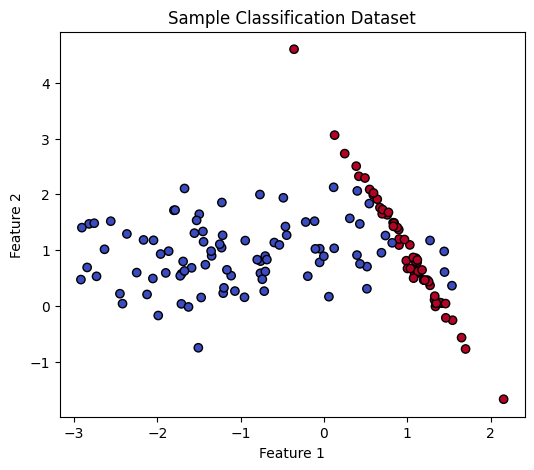

In [2]:
# creating a binary classification dataset
X, y = make_classification(
    n_samples=150,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.6, 0.4],
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Sample Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# **Implementation**

In [3]:
def precision_recall_f1_custom(y_true, y_pred):
    # convert to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # calculate components of confusion matrix
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

In [5]:
np.random.seed(0)
y_pred = y.copy()
flip_indices = np.random.choice(len(y), size=15, replace=False)
y_pred[flip_indices] = 1 - y_pred[flip_indices]

# use custom function
p_custom, r_custom, f_custom = precision_recall_f1_custom(y, y_pred)

print("Custom Implementation Results:")
print(f"Precision: {p_custom:.3f}")
print(f"Recall:    {r_custom:.3f}")
print(f"F1 Score:  {f_custom:.3f}")

Custom Implementation Results:
Precision: 0.869
Recall:    0.883
F1 Score:  0.876


In [7]:
# verify results using sklearn
p_sklearn = precision_score(y, y_pred)
r_sklearn = recall_score(y, y_pred)
f_sklearn = f1_score(y, y_pred)

print("\n Sklearn Results:")
print(f"Precision: {p_sklearn:.3f}")
print(f"Recall:    {r_sklearn:.3f}")
print(f"F1 Score:  {f_sklearn:.3f}")

assert np.isclose(p_custom, p_sklearn), "Precision mismatch!"
assert np.isclose(r_custom, r_sklearn), "Recall mismatch!"
assert np.isclose(f_custom, f_sklearn), "F1 mismatch!"


 Sklearn Results:
Precision: 0.869
Recall:    0.883
F1 Score:  0.876


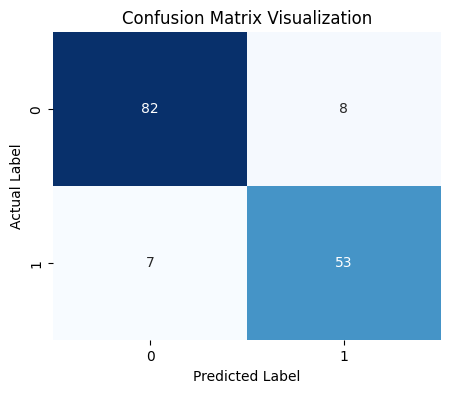

In [8]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix Visualization")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()